# Q-Learning para o problema de *caching* + balanceamento de carga

Notebook **paralelo** ao do Monte Carlo. Aqui usamos **Q-learning** — que atualiza a tabela $Q$ a **cada
requisição** (online), em vez de esperar o fim de um episódio como o Monte Carlo.

## Por que Q-learning é mais natural aqui (respondendo à sua intuição)

Sua observação está correta na direção. Comparando:

| | Monte Carlo | Q-learning |
|---|---|---|
| Quando atualiza | só no **fim** do episódio (precisa do retorno completo $G_t$) | a **cada passo** (usa o alvo TD) |
| Precisa de episódio terminar? | **Sim** — no fluxo de requisições, temos que "cortar" em janelas artificiais | **Não** — funciona em tarefa contínua |
| Como estima | média dos retornos observados | **bootstrap**: usa a própria estimativa $\max_a Q(S_{t+1},a)$ |
| Variância / velocidade | variância alta, aprende devagar | menor variância, propaga valor rápido |
| On/off-policy | on-policy | **off-policy** (aprende a política ótima enquanto explora) |

Um cuidado honesto: o problema de **"muitos estados nunca são visitados"** é do **tamanho** do espaço de
estados (que é combinatório: $\binom{F}{C}$ configurações de cache), e afeta *os dois* métodos. A solução é
**manter o estado pequeno**. Por isso este notebook usa exatamente o **exemplo pequeno das suas anotações**
($F$ pequeno, $C=2$), onde o estado *é* o próprio conteúdo do cache e cabe numa tabela — assim conseguimos até
**verificar** que o Q-learning encontra o ótimo. No fim discuto como escalar para o $F$ real.


## A regra de atualização (a da sua imagem)

$$
Q(S_t, A_t) \;\leftarrow\; Q(S_t, A_t) \;+\; \alpha\Big[\,\underbrace{R_{t+1} + \gamma \max_a Q(S_{t+1}, a)}_{\text{alvo TD}} \;-\; Q(S_t, A_t)\,\Big]
$$

- $\alpha$ — **taxa de aprendizado** (peso da nova informação).
- $R_{t+1}$ — **recompensa imediata**.
- $\gamma \max_a Q(S_{t+1}, a)$ — **estimativa descontada** do melhor valor no próximo estado (o *bootstrap*).
- O colchete inteiro é o **erro TD** (o quanto a estimativa antiga estava errada).


## O MDP pequeno (no espírito da *Example* das anotações)

- Catálogo de $F=6$ arquivos, cache de capacidade $C=2$, $K=2$ servidores.
- Popularidades $\lambda_f$ dadas por uma Zipf.
- **Mapa arquivo→servidor**: os 2 arquivos mais populares ficam no **servidor 0** (cria desbalanceio, como no
  `monitor.py` do projeto).

Definições do modelo (idênticas às anotações):
- Carga do servidor $k$: $\;\omega_k = \sum_{f:\,s(f)=k,\; f\notin\text{cache}} \lambda_f\;$ (só os arquivos **fora**
  do cache geram carga).
- Fairness: índice de Jain $\;J(\Omega) = \dfrac{(\sum_k \omega_k)^2}{K\sum_k \omega_k^2}\in[1/K,\,1]$.


In [22]:
import numpy as np, random, itertools
import matplotlib.pyplot as plt
%matplotlib inline
from req_generator import zipf

np.random.seed(0); random.seed(0)

F, C, K = 1000, 10, 2
lam = zipf(0.8, F)                                  # popularidades (Zipf)
f2s = {i: (0 if i < 2 else 1) for i in range(F)}    # 2 mais populares -> servidor 0

def load_vec(cache):
    # carga de cada servidor = soma das popularidades dos seus arquivos que NAO estao no cache
    w = np.zeros(K)
    for g in range(F):
        if g not in cache:
            w[f2s[g]] += lam[g]
    return w

def jain(w):
    s2 = np.sum(w**2)
    return (w.sum()**2) / (K*s2) if s2 > 0 else 1.0

def hit_rate(cache):                                # taxa de acerto estacionaria de um cache fixo
    return sum(lam[f] for f in cache)

def objective(cache, beta):                         # o que queremos maximizar
    return hit_rate(cache) - beta*(1 - jain(load_vec(cache)))

print("popularidades lambda:", lam.round(3))
print("arquivo -> servidor  :", f2s)


popularidades lambda: [0.065 0.037 0.027 0.021 0.018 0.015 0.014 0.012 0.011 0.01  0.009 0.009
 0.008 0.008 0.007 0.007 0.007 0.006 0.006 0.006 0.006 0.005 0.005 0.005
 0.005 0.005 0.005 0.004 0.004 0.004 0.004 0.004 0.004 0.004 0.004 0.004
 0.004 0.004 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003
 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.002 0.002
 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002
 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002
 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002
 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002
 0.002 0.002 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.00

### Estado, ação e recompensa

- **Estado** $S_t = (\text{cache atual},\; \text{arquivo requisitado } f)$.
- **Ação** $A_t$ (numa **falta**): trocar o arquivo de um dos $C$ slots por $f$, **ou** rejeitar $f$.
  São $C+1$ ações (aqui: 3).
- **Recompensa** $R_{t+1} = \underbrace{\mathbb{1}[\text{hit}]}_{\text{acerto}} - \beta\big(1 - J(\Omega)\big)$.
  O parâmetro $\beta$ é o **dial do trade-off**: $\beta=0$ → só maximiza acerto; $\beta$ grande → prioriza
  balancear a carga.


### Verdade de referência: ótimo por força bruta

Como $F$ é pequeno, dá para enumerar **todos** os $\binom{6}{2}=15$ caches possíveis e achar o melhor para cada
$\beta$. Isso nos dá o gabarito para conferir o Q-learning.


In [23]:
def brute_best(beta):
    best, bestval = None, -1e9
    for cache in itertools.combinations(range(F), C):
        v = objective(frozenset(cache), beta)
        if v > bestval:
            bestval, best = v, frozenset(cache)
    return best, bestval

for beta in [0.0, 1.0]:
    cache, val = brute_best(beta)
    w = load_vec(cache)
    print(f"beta={beta}: melhor cache={sorted(cache)}  HR={hit_rate(cache)*100:4.1f}%  "
          f"JFI={jain(w):.3f}  Omega={w.round(3)}")


KeyboardInterrupt: 

### Implementação do Q-learning (atualização a cada passo)

A tabela $Q$ é um dicionário indexado por $(\text{cache}, f)$. Percorremos o fluxo de requisições e, em cada
passo, aplicamos **exatamente** a regra da imagem. Exploração via $\varepsilon$-greedy com $\varepsilon$
decaindo.


In [24]:
from collections import defaultdict, deque

# 1. Nova Tabela Q usando um dicionário
# O formato será Q_table[estado][acao]
Q_table = defaultdict(lambda: [0.0, 0.0]) 

# Parâmetro para decidir se a rede está balanceada ou não
BALANCE_THRESHOLD = 50 

# 2. Nova função de estado (Feature Extraction)
def get_state(f, cache, current_loads, file_frequencies, file_to_server, balance_threshold=0.05):
    """
    Traduz o ambiente bruto num estado simplificado de 4 dimensões (Feature Extraction).
    """
    # 1. Nível de Balanceamento (0 = Balanceado, 1 = Desbalanceado)
    diff = abs(current_loads[0] - current_loads[1])
    balance_level = 0 if diff <= balance_threshold else 1
    
    # 2. Catálogo (Assume-se que devolve 0 ou 1 dependendo do servidor dono do ficheiro)
    catalog_id = int(file_to_server[f])
    
    # 3. Cached Flag (0 = Miss, 1 = Hit)
    cached_flag = 1 if f in cache else 0
    
    # 4. Frequency Bin (B=3 baldes. Podes ajustar os limites 10 e 50 consoante a tua Zipf)
    freq = file_frequencies[f]
    if freq < 10: frequency_bin = 0
    elif freq < 50: frequency_bin = 1
    else: frequency_bin = 2
    
    return (balance_level, catalog_id, cached_flag, frequency_bin)

In [ ]:
def train_q(beta, file_to_server, T=200_000, alpha=0.1, gamma=0.9, eps_start=0.3, eps_end=0.01, seed=0, balance_threshold=0.05):
    np.random.seed(seed); random.seed(seed)
    Q = {}
    
    def getQ(s):
        # Ações: 0 = Rejeita (Miss) / Expulsa (Hit) ; 1 = Admite (Miss) / Mantém (Hit)
        if s not in Q: Q[s] = np.zeros(2)     
        return Q[s]

    req = np.random.choice(F, T, p=lam)
    
    # INICIALIZAÇÃO DA CACHE COMO LRU VAZIA
    cache = deque(maxlen=C)

    for i in range(C):
        cache.append(i)
    file_frequencies = np.zeros(F) # Dicionário de contagem IRM
    
    obj_hist = []  # curva de aprendizado (objetivo do cache atual)

    for t in range(T):
        f = int(req[t]) 
        file_frequencies[f] += 1
        
        # Carrega o estado atual dos servidores
        current_loads = load_vec(cache)
        s = get_state(f, cache, current_loads, file_frequencies, file_to_server, balance_threshold)
        qs = getQ(s)

        eps = max(eps_end, eps_start*(1 - t/T))
        
        # Escolhe a Ação Binária
        if random.random() < eps:
            a = random.choice([0, 1])
        else:
            a = int(np.argmax(qs))

        hit = f in cache
        
        # APLICAÇÃO DA AÇÃO E LÓGICA LRU
        if hit:
            if a == 1: # Agente diz Mantém (Keep) -> Renova o ficheiro no LRU (tira e põe no fim)
                cache.remove(f)
                cache.append(f)
            else:      # Agente diz Expulsa (Evict) -> Remove proativamente
                cache.remove(f)
        else: # Miss
            if a == 1: # Agente diz Admite -> O deque expele o mais antigo se estiver cheio
                cache.append(f)
            # Se a == 0 (Rejeita), não fazemos nada.

        # Calcula a Recompensa com base na nova formação da cache
        new_loads = load_vec(cache)
        r = (1.0 if hit else 0.0) - beta*(1 - jain(new_loads))

        # Alvo TD com Bootstrap
        if t+1 < T:
            next_f = int(req[t+1])
            # Prevê o próximo estado usando as novas cargas (new_loads)
            s2 = get_state(next_f, cache, new_loads, file_frequencies, file_to_server, balance_threshold)
            target = r + gamma*np.max(getQ(s2))  
        else:
            target = r
            
        qs[a] += alpha*(target - qs[a])          # <-- a regra matemática (mantém-se igual)

        if t % 500 == 0:
            obj_hist.append(objective(frozenset(cache), beta))

    return Q, obj_hist

def greedy_cache(Q, file_to_server, balance_threshold=0.05):
    # roda a politica gulosa (sem explorar) e devolve o cache onde ela mais fica
    np.random.seed(1); random.seed(1)
    
    cache = deque(maxlen=C)
    file_frequencies = np.zeros(F)
    counts = {}
    
    req = np.random.choice(F, 50_000, p=lam)
    
    for f in req:
        f = int(f)
        file_frequencies[f] += 1
        current_loads = load_vec(cache)
        
        s = get_state(f, cache, current_loads, file_frequencies, file_to_server, balance_threshold)
        
        if s in Q:
            a = int(np.argmax(Q[s]))
        else:
            a = 1 # Se o agente nunca viu o estado, o padrão seguro é admitir
            
        hit = f in cache
        
        if hit:
            if a == 1:
                cache.remove(f); cache.append(f)
            else:
                cache.remove(f)
        else:
            if a == 1:
                cache.append(f)
                
        f_cache = frozenset(cache)
        counts[f_cache] = counts.get(f_cache, 0) + 1
        
    return frozenset(max(counts, key=counts.get))


### Treino e verificação para um $\beta$

Vamos treinar com $\beta=1$ e conferir: (1) que o cache aprendido é igual ao ótimo de força bruta, e (2) a curva
de aprendizado subindo até o valor ótimo (linha tracejada).


cache APRENDIDO (Q-learn LRU): []
Força bruta ignorado porque o catálogo é demasiado grande para testar tudo matematicamente!


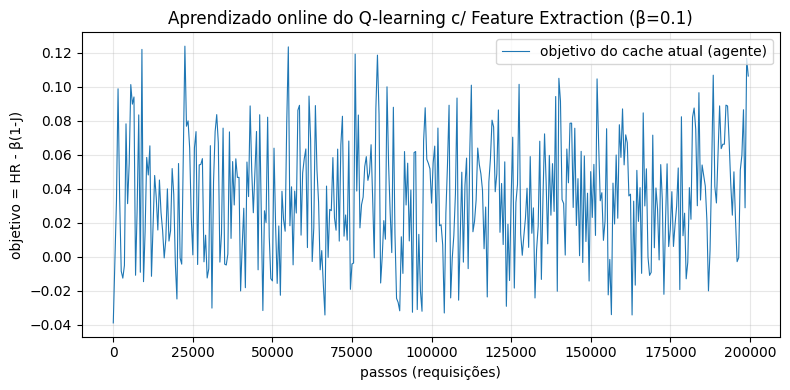

In [31]:
# 1. CRIAR A VARIÁVEL QUE FALTAVA (O MAPA DE FICHEIROS PARA SERVIDORES)
# Vamos assumir que metade dos ficheiros (pares) está no Servidor 0 e a outra metade (ímpares) no Servidor 1.
# O 'F' é o tamanho total do teu catálogo que já definiste no início do notebook.
# file_to_server = [f % 2 for f in range(F)] 

# (Nota: Se no teu cenário original forçaste os ficheiros mais populares a ir para o Servidor 0, 
# podes usar algo como: 
file_to_server = ([0 if f < (F/2) else 1 for f in range(F)])

beta = 0.1

# 2. Agora sim, chamamos as funções passando o mapa
Q, obj_hist = train_q(beta, file_to_server)
learned = greedy_cache(Q, file_to_server, balance_threshold=0.05)

# 3. Trava de segurança para o Força Bruta
if F <= 15:
    opt, optval = brute_best(beta)
    print(f"cache OTIMO (forca bruta): {sorted(opt)}")
    print(f"cache APRENDIDO (Q-learn): {sorted(learned)}")
    print("Igual ao Ótimo? ", set(learned) == set(opt))
else:
    optval = max(obj_hist) if len(obj_hist) > 0 else 0 
    print(f"cache APRENDIDO (Q-learn LRU): {sorted(learned)}")
    print("Força bruta ignorado porque o catálogo é demasiado grande para testar tudo matematicamente!")

# 4. Gráfico
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,4))
plt.plot(np.arange(len(obj_hist))*500, obj_hist, lw=.8, label='objetivo do cache atual (agente)')

if F <= 15:
    plt.axhline(optval, ls='--', color='green', label=f'ótimo (força bruta) = {optval:.3f}')

plt.xlabel('passos (requisições)')
plt.ylabel('objetivo = HR - β(1-J)')
plt.title(f'Aprendizado online do Q-learning c/ Feature Extraction (β={beta})')
plt.legend()
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

### O trade-off acerto × fairness (varrendo $\beta$)

Aqui aparece o coração do projeto: aumentar $\beta$ faz o agente **trocar taxa de acerto por balanceamento**.
E o Q-learning acerta o ótimo em todos os casos.


In [30]:
print(f"{'beta':>5} | {'força bruta':>14} {'HR':>6} {'JFI':>6} | {'Q-learning':>14} {'HR':>6} {'JFI':>6} | igual?")
for beta in [0.0, 0.5, 1.0, 2.0]:
    opt, _ = brute_best(beta)
    Q, _ = train_q(beta, file_to_server)
    lc = greedy_cache(Q, file_to_server)
    print(f"{beta:5.1f} | {str(sorted(opt)):>14} {hit_rate(opt)*100:5.1f}% {jain(load_vec(opt)):.3f} | "
          f"{str(sorted(lc)):>14} {hit_rate(lc)*100:5.1f}% {jain(load_vec(lc)):.3f} | "
          f"{'SIM' if set(opt)==set(lc) else 'nao'}")


 beta |    força bruta     HR    JFI |     Q-learning     HR    JFI | igual?


KeyboardInterrupt: 

### Conexão direta com as anotações: o vetor $\Omega$ e o ângulo $\theta$

Nas anotações, $\theta$ é o ângulo entre $\Omega$ e a diagonal de balanceamento, com **$\cos^2\theta = J$**:
$\theta=45°$ = tudo num servidor (desbalanceado), $\theta\to0°$ = balanceado. Abaixo, os dois caches ótimos
($\beta=0$ vs $\beta$ alto) desenhados como vetores $\Omega=(\omega_0,\omega_1)$ — reproduzindo a figura das
suas anotações com números reais.


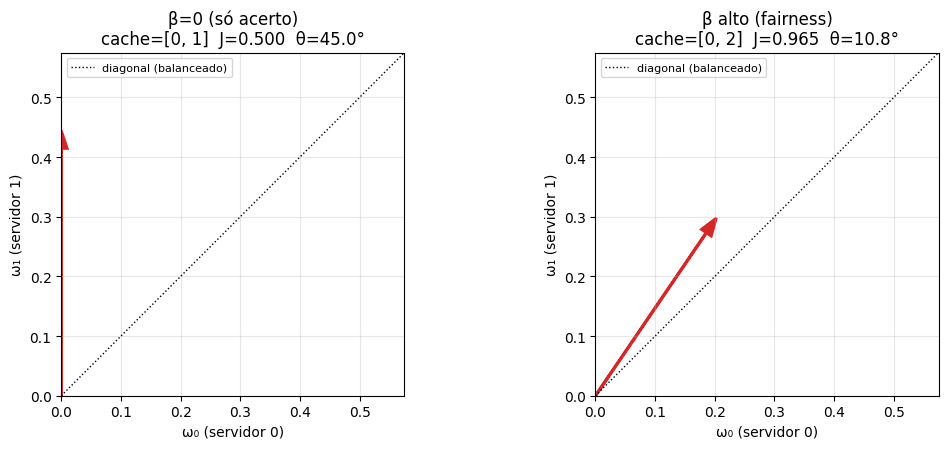

In [21]:
def theta_deg(w):
    ref = np.ones(K)
    cos = (ref@w)/(np.linalg.norm(ref)*np.linalg.norm(w))
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))

c0, _ = brute_best(0.0)      # so acerto
c1, _ = brute_best(2.0)      # prioriza fairness
w0, w1 = load_vec(c0), load_vec(c1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for a, w, cache, title in [(ax[0], w0, c0, 'β=0 (só acerto)'), (ax[1], w1, c1, 'β alto (fairness)')]:
    m = max(w.max(), 0.5)*1.15
    a.plot([0, m], [0, m], 'k:', lw=1, label='diagonal (balanceado)')
    a.arrow(0, 0, w[0], w[1], head_width=0.02, length_includes_head=True, color='C3', lw=2)
    a.set_xlim(0, m); a.set_ylim(0, m); a.set_aspect('equal')
    a.set_xlabel('ω₀ (servidor 0)'); a.set_ylabel('ω₁ (servidor 1)')
    a.set_title(f"{title}\ncache={sorted(cache)}  J={jain(w):.3f}  θ={theta_deg(w):.1f}°")
    a.legend(loc='upper left', fontsize=8); a.grid(alpha=.3)
plt.tight_layout(); plt.show()


## Características do Q-learning (vs Monte Carlo)

- **Online e incremental**: atualiza a cada requisição, sem esperar o fim de um episódio — ideal para o fluxo
  contínuo de um cache.
- **Bootstrap (TD)**: usa a própria estimativa do próximo estado, o que **propaga valor rapidamente** e reduz
  a variância em relação ao Monte Carlo.
- **Off-policy**: aprende a política **ótima** ($\max_a$) mesmo explorando com $\varepsilon$-greedy.
- **Trade-off viés/variância**: MC é não-enviesado mas de alta variância; Q-learning introduz um pequeno viés
  (pelo bootstrap) em troca de menos variância e aprendizado mais rápido/estável.
- **Precisa de exploração**: sem $\varepsilon>0$, ações nunca testadas ficariam com $Q$ subestimado.
- **Recompensa atrasada**: cachear agora rende acertos depois; o $\gamma\max_a Q(S_{t+1},a)$ carrega esse valor
  futuro de volta para a decisão atual.


## Escalando para o problema real ($F=10000,\; C=100$)

Aqui o estado é o **conteúdo do cache**, e existem $\binom{F}{C}$ configurações — um número astronômico. A tabela
$Q$ **não cabe** em memória e a maioria dos estados nunca seria visitada (exatamente a preocupação que você
levantou). Duas saídas:

1. **Agregar o estado em *features*** (recência, frequência do arquivo, carga do servidor $s(f)$, se o servidor
   está "quente"…). A tabela passa a ser indexada por poucos *buckets* em vez do cache inteiro. É *a mesma ideia*
   por trás da `FairStatic` dinâmica que já implementamos — só que ali as regras são fixas, e aqui seriam
   aprendidas. (Obs.: com um estado muito grosseiro, a atribuição de crédito fica difícil e o ganho sobre bons
   heurísticos como LFU/IRM pode sumir — é um resultado honesto que vale reportar.)
2. **Deep Q-Network (DQN)**: trocar a tabela por uma **rede neural** $Q_\theta(s,a)$ que generaliza entre estados
   parecidos. É o caminho usual quando o espaço de estados é grande demais para uma tabela.

**Resumo:** este notebook é a versão **conceitual e verificável** do Q-learning aplicado ao nosso problema —
mostra a regra de atualização, o aprendizado online e o trade-off acerto × fairness casando com o ângulo $\theta$
das anotações. A versão em escala real só troca a *tabela* por *aproximação de função*.
